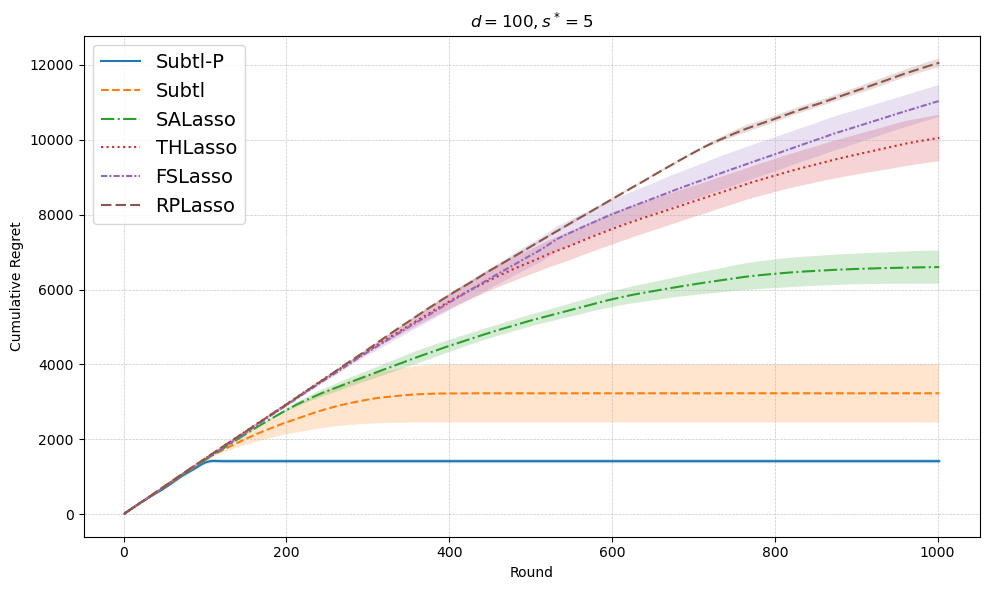

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import savgol_filter

# List of file paths and corresponding LaTeX-style labels
file_paths = [
    "cumulative_regret_pre-lasso-stochastic-bandit-d100-s5_10times.npy",
    "cumulative_regret_lasso-stochastic-bandit-d100-s5_10times.npy",
    "cumulative_regret_SA-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_thresholded-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_force-sampling-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_lasso-random-projection-bandit-d100-s5_10times.npy"
]

custom_labels = [
    "Subtl-P",
    "Subtl",
    "SALasso",
    "THLasso",
    "FSLasso",
    "RPLasso"
]


# Dictionary to store processed data (mean and std)
mean_std_data = {}

# Define line styles for the plot
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

# Function to smooth data using Savitzky-Golay filter
def smooth_data(data, window_size, poly_order=2):
    if window_size % 2 == 0:  # Ensure window size is odd
        window_size += 1
    return savgol_filter(data, window_size, poly_order)

# Process each file
for file_path, label in zip(file_paths, custom_labels):
    if os.path.exists(file_path):
        # Load .npy file (assumes data shape is [runs, rounds])
        data = np.load(file_path)
        
        # Compute mean and standard deviation across runs
        mean_data = np.mean(data, axis=0)
        std_data = np.std(data, axis=0)
        
        # Smooth the mean data
        window_size = min(35, len(mean_data))
        smoothed_mean_data = smooth_data(mean_data, window_size)
        
        # Store smoothed mean and std in the dictionary
        mean_std_data[label] = (smoothed_mean_data, std_data)
    else:
        print(f"File not found: {file_path}")

# Plot cumulative regret with confidence intervals
plt.figure(figsize=(10, 6))

for (label, (mean_data, std_data)), line_style in zip(mean_std_data.items(), line_styles):
    time_steps = np.arange(1, len(mean_data) + 1)
    
    # Plot the smoothed mean line
    plt.plot(time_steps, mean_data, label=label, linestyle=line_style)
    
    # Compute and plot the 95% confidence interval
    ci_lower = mean_data - 1.96 * (std_data / np.sqrt(data.shape[0]))
    ci_upper = mean_data + 1.96 * (std_data / np.sqrt(data.shape[0]))
    plt.fill_between(time_steps, ci_lower, ci_upper, alpha=0.2)

# Set axis labels and plot title
plt.xlabel("Round")
plt.ylabel("Cumulative Regret")
plt.title(r"$d=100, s^*=5$")  # LaTeX-style title

# Add grid, legend, and adjust layout
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=14)
plt.tight_layout()

# Show the plot
plt.show()


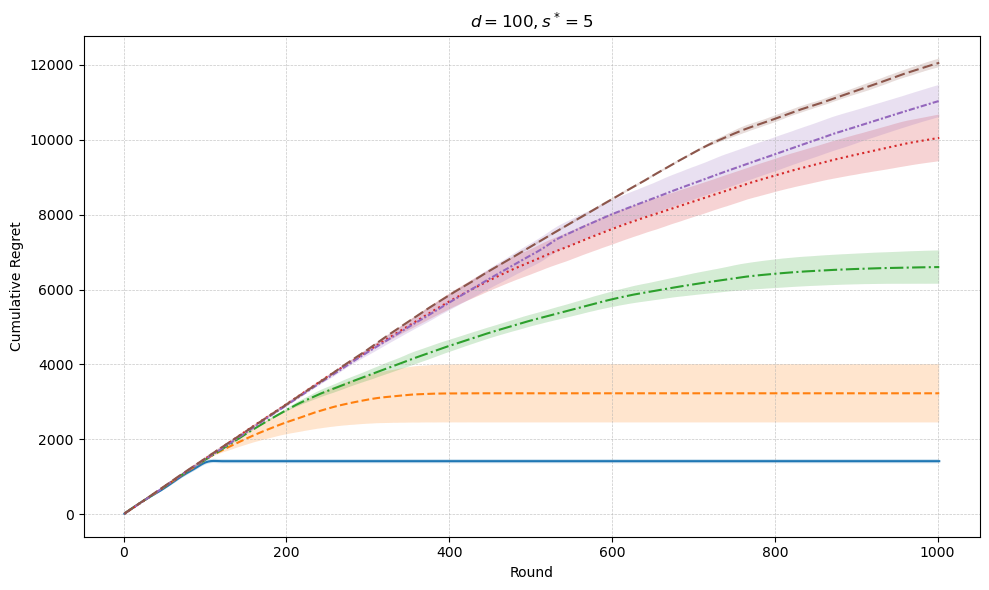

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import savgol_filter

# List of file paths and corresponding LaTeX-style labels
file_paths = [
    "cumulative_regret_pre-lasso-stochastic-bandit-d100-s5_10times.npy",
    "cumulative_regret_lasso-stochastic-bandit-d100-s5_10times.npy",
    "cumulative_regret_SA-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_thresholded-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_force-sampling-lasso-bandit-d100-s5_10times.npy",
    "cumulative_regret_lasso-random-projection-bandit-d100-s5_10times.npy"
]

custom_labels = [
    "Subtl-P",
    "Subtl",
    "SALasso",
    "THLasso",
    "FSLasso",
    "RPLasso"
]


# Dictionary to store processed data (mean and std)
mean_std_data = {}

# Define line styles for the plot
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

# Function to smooth data using Savitzky-Golay filter
def smooth_data(data, window_size, poly_order=2):
    if window_size % 2 == 0:  # Ensure window size is odd
        window_size += 1
    return savgol_filter(data, window_size, poly_order)

# Process each file
for file_path, label in zip(file_paths, custom_labels):
    if os.path.exists(file_path):
        # Load .npy file (assumes data shape is [runs, rounds])
        data = np.load(file_path)
        
        # Compute mean and standard deviation across runs
        mean_data = np.mean(data, axis=0)
        std_data = np.std(data, axis=0)
        
        # Smooth the mean data
        window_size = min(35, len(mean_data))
        smoothed_mean_data = smooth_data(mean_data, window_size)
        
        # Store smoothed mean and std in the dictionary
        mean_std_data[label] = (smoothed_mean_data, std_data)
    else:
        print(f"File not found: {file_path}")

# Plot cumulative regret with confidence intervals
plt.figure(figsize=(10, 6))

for (label, (mean_data, std_data)), line_style in zip(mean_std_data.items(), line_styles):
    time_steps = np.arange(1, len(mean_data) + 1)
    
    # Plot the smoothed mean line
    plt.plot(time_steps, mean_data, label=label, linestyle=line_style)
    
    # Compute and plot the 95% confidence interval
    ci_lower = mean_data - 1.96 * (std_data / np.sqrt(data.shape[0]))
    ci_upper = mean_data + 1.96 * (std_data / np.sqrt(data.shape[0]))
    plt.fill_between(time_steps, ci_lower, ci_upper, alpha=0.2)

# Set axis labels and plot title
plt.xlabel("Round")
plt.ylabel("Cumulative Regret")
plt.title(r"$d=100, s^*=5$")  # LaTeX-style title

# Add grid, legend, and adjust layout
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()
